In [20]:
from pathlib import Path
import json
import random
import time
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy.sparse as sp
import scanpy as sc

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

import scgpt

from scgpt.model import TransformerModel
from scgpt.tokenizer import GeneVocab, tokenize_and_pad_batch
from scgpt.preprocess import Preprocessor
from scgpt.utils import load_pretrained

In [62]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = Path("../data")
RESULTS_DIR = Path("../results")
FIGURES_DIR = Path("../figures")
MODEL_DIR = Path("../models")

SCGPT_MODEL_DIR = MODEL_DIR / "scGPT_human"
FINETUNE_DIR = MODEL_DIR / "scGPT_finetuned"
FROZEN_DIR = MODEL_DIR / "scGPT_frozen"

FROZEN_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

vocab_file = SCGPT_MODEL_DIR / "vocab.json"
config_file = SCGPT_MODEL_DIR / "args.json"
model_file = SCGPT_MODEL_DIR / "best_model.pt"

N_BINS = 51
MAX_SEQ_LEN = 1024

BATCH_SIZE = 8
EVAL_BATCH_SIZE = 16

LEARNING_RATE = 1e-4

EPOCHS = 5
PATIENCE = 2

In [22]:
if torch.cuda.is_available():
    device = torch.device("cuda")

elif (
    hasattr(torch.backends, "mps")
    and torch.backends.mps.is_available()
):
    device = torch.device("mps")

else:
    device = torch.device("cpu")

print("Device:", device)

Device: mps


In [23]:
adata_train = sc.read_h5ad(
    DATA_DIR / "train_raw.h5ad"
)

adata_val = sc.read_h5ad(
    DATA_DIR / "val_raw.h5ad"
)

adata_test = sc.read_h5ad(
    DATA_DIR / "test_raw.h5ad"
)

print("Train:", adata_train.shape)
print("Val:  ", adata_val.shape)
print("Test: ", adata_test.shape)

Train: (32252, 20889)
Val:   (10866, 20889)
Test:  (15217, 20889)


In [24]:
#SAME DONOR SPLIT
adata_train = sc.read_h5ad(
    DATA_DIR / "train_raw.h5ad"
)

adata_val = sc.read_h5ad(
    DATA_DIR / "val_raw.h5ad"
)

adata_test = sc.read_h5ad(
    DATA_DIR / "test_raw.h5ad"
)

print("Train:", adata_train.shape)
print("Val:  ", adata_val.shape)
print("Test: ", adata_test.shape)

Train: (32252, 20889)
Val:   (10866, 20889)
Test:  (15217, 20889)


In [25]:
#SAME HVG'S
with open(
    RESULTS_DIR / "baseline_hvg_ids.json"
) as f:

    hvg_ids = json.load(f)

print("Saved HVGs:", len(hvg_ids))

# Keep only the training-derived HVGs that exist in all three splits
shared_hvgs = [
    gene
    for gene in hvg_ids
    if (
        gene in adata_train.var_names
        and gene in adata_val.var_names
        and gene in adata_test.var_names
    )
]

print("Shared HVGs:", len(shared_hvgs))

# Subset all splits to exactly the same HVG set
adata_train = adata_train[:, shared_hvgs].copy()
adata_val = adata_val[:, shared_hvgs].copy()
adata_test = adata_test[:, shared_hvgs].copy()

print("After HVG subsetting:")
print("Train:", adata_train.shape)
print("Val:  ", adata_val.shape)
print("Test: ", adata_test.shape)

Saved HVGs: 2000
Shared HVGs: 2000
After HVG subsetting:
Train: (32252, 2000)
Val:   (10866, 2000)
Test:  (15217, 2000)


In [26]:
#Load same vocab 
vocab = GeneVocab.from_file(
    vocab_file
)

special_tokens = [
    "<pad>",
    "<cls>",
    "<eoc>",
]

for token in special_tokens:
    if token not in vocab:
        vocab.append_token(token)

vocab.set_default_index(
    vocab["<pad>"]
)

print("Vocabulary size:", len(vocab))

Vocabulary size: 60697


In [27]:
gene_names = (
    adata_train.var["gene_name"]
    .astype(str)
)

in_vocab = np.array([
    gene in vocab
    for gene in gene_names
])

print(
    f"Matched genes: "
    f"{in_vocab.sum()} / "
    f"{len(in_vocab)}"
)

Matched genes: 1468 / 2000


In [28]:
#same filtering
matched_var_names = (
    adata_train.var_names[
        in_vocab
    ]
    .tolist()
)

adata_train = adata_train[
    :, matched_var_names
].copy()

adata_val = adata_val[
    :, matched_var_names
].copy()

adata_test = adata_test[
    :, matched_var_names
].copy()


In [29]:
#remove duplicate gene names
gene_names = (
    adata_train.var["gene_name"]
    .astype(str)
)

keep_unique = (
    ~gene_names.duplicated()
)

unique_var_names = (
    adata_train.var_names[
        keep_unique
    ]
    .tolist()
)

adata_train = adata_train[
    :, unique_var_names
].copy()

adata_val = adata_val[
    :, unique_var_names
].copy()

adata_test = adata_test[
    :, unique_var_names
].copy()

print(
    "Final scGPT genes:",
    adata_train.n_vars,
)

Final scGPT genes: 1468


In [30]:
#same label mapping
with open(
    FINETUNE_DIR /
    "celltype_mapping.json"
) as f:

    mappings = json.load(f)

In [31]:
type2id = {
    str(key): int(value)
    for key, value
    in mappings["type2id"].items()
}

id2type = {
    int(key): value
    for key, value
    in mappings["id2type"].items()
}

num_types = len(type2id)

celltypes = [
    id2type[i]
    for i in range(num_types)
]

print("Classes:", num_types)

for i, name in id2type.items():
    print(i, name)

Classes: 8
0 monocyte
1 CD8-positive, alpha-beta T cell
2 CD4-positive, alpha-beta T cell
3 B cell
4 natural killer cell
5 alpha-beta T cell
6 dendritic cell
7 platelet


In [32]:
#add ID's
for adata_split in [
    adata_train,
    adata_val,
    adata_test,
]:

    labels = (
        adata_split.obs[
            "cell_type"
        ]
        .astype(str)
    )

    assert labels.isin(
        type2id.keys()
    ).all()

    adata_split.obs[
        "celltype_id"
    ] = (
        labels
        .map(type2id)
        .astype(int)
    )

In [33]:
#same preprocessing
preprocessor = Preprocessor(
    use_key="X",

    filter_gene_by_counts=False,
    filter_cell_by_counts=False,

    normalize_total=1e4,
    result_normed_key="X_normed",

    log1p=True,
    result_log1p_key="X_log1p",

    subset_hvg=False,

    binning=N_BINS,
    result_binned_key="X_binned",
)

In [34]:
print("Training...")
preprocessor(
    adata_train,
    batch_key=None,
)

print("Validation...")
preprocessor(
    adata_val,
    batch_key=None,
)

print("Test...")
preprocessor(
    adata_test,
    batch_key=None,
)

print("Done.")

Training...
scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Log1p transforming ...
scGPT - INFO - Binning data ...
Validation...
scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Log1p transforming ...
scGPT - INFO - Binning data ...
Test...
scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Log1p transforming ...
scGPT - INFO - Binning data ...
Done.


In [35]:
#gene id
genes = (
    adata_train.var[
        "gene_name"
    ]
    .astype(str)
    .tolist()
)

gene_ids = np.array(
    vocab(genes),
    dtype=int,
)

print(
    "Number of gene tokens:",
    len(gene_ids),
)

Number of gene tokens: 1468


In [36]:
#same binned matrix
def get_binned_matrix(adata):

    X = adata.layers[
        "X_binned"
    ]

    if sp.issparse(X):
        X = X.toarray()

    return np.asarray(X)

train_counts = get_binned_matrix(
    adata_train
)

val_counts = get_binned_matrix(
    adata_val
)

test_counts = get_binned_matrix(
    adata_test
)

print(train_counts.shape)
print(val_counts.shape)
print(test_counts.shape)

(32252, 1468)
(10866, 1468)
(15217, 1468)


In [39]:
#Tokenize
PAD_TOKEN = "<pad>"
PAD_VALUE = -2

tokenized_train = tokenize_and_pad_batch(
    train_counts,
    gene_ids,

    max_len=MAX_SEQ_LEN,

    vocab=vocab,

    pad_token=PAD_TOKEN,
    pad_value=PAD_VALUE,

    append_cls=True,
    include_zero_gene=False,
)

tokenized_val = tokenize_and_pad_batch(
    val_counts,
    gene_ids,

    max_len=MAX_SEQ_LEN,

    vocab=vocab,

    pad_token=PAD_TOKEN,
    pad_value=PAD_VALUE,

    append_cls=True,
    include_zero_gene=False,
)

tokenized_test = tokenize_and_pad_batch(
    test_counts,
    gene_ids,

    max_len=MAX_SEQ_LEN,

    vocab=vocab,

    pad_token=PAD_TOKEN,
    pad_value=PAD_VALUE,

    append_cls=True,
    include_zero_gene=False,
)

del train_counts
del val_counts
del test_counts

gc.collect()

0

In [40]:
class CellDataset(Dataset):

    def __init__(
        self,
        tokenized,
        labels,
    ):

        self.genes = (
            tokenized["genes"]
        )

        self.values = (
            tokenized["values"]
        )

        self.labels = torch.tensor(
            labels,
            dtype=torch.long,
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        return {
            "gene_ids":
                self.genes[idx],

            "values":
                self.values[idx],

            "labels":
                self.labels[idx],
        }

In [41]:
y_train = (
    adata_train.obs[
        "celltype_id"
    ]
    .to_numpy(dtype=int)
)

y_val = (
    adata_val.obs[
        "celltype_id"
    ]
    .to_numpy(dtype=int)
)

y_test = (
    adata_test.obs[
        "celltype_id"
    ]
    .to_numpy(dtype=int)
)

train_dataset = CellDataset(
    tokenized_train,
    y_train,
)

val_dataset = CellDataset(
    tokenized_val,
    y_val,
)

test_dataset = CellDataset(
    tokenized_test,
    y_test,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

In [42]:
with open(config_file) as f:
    model_config = json.load(f)

embsize = model_config["embsize"]
nhead = model_config["nheads"]
d_hid = model_config["d_hid"]
nlayers = model_config["nlayers"]
n_layers_cls = model_config[
    "n_layers_cls"
]
dropout = model_config["dropout"]

In [43]:
torch.manual_seed(SEED)

frozen_model = TransformerModel(
    ntoken=len(vocab),

    d_model=embsize,
    nhead=nhead,
    d_hid=d_hid,
    nlayers=nlayers,

    nlayers_cls=n_layers_cls,
    n_cls=num_types,

    vocab=vocab,

    dropout=dropout,

    pad_token=PAD_TOKEN,
    pad_value=PAD_VALUE,

    do_mvc=False,
    do_dab=False,

    use_batch_labels=False,
    num_batch_labels=None,

    domain_spec_batchnorm=False,

    input_emb_style="continuous",
    n_input_bins=N_BINS,

    cell_emb_style="cls",

    mvc_decoder_style=
        "inner product",

    ecs_threshold=0.0,
    explicit_zero_prob=False,

    use_fast_transformer=False,

    pre_norm=False,
)

In [44]:
pretrained_dict = torch.load(
    model_file,
    map_location="cpu",
    weights_only=False,
)

frozen_model = load_pretrained(
    frozen_model,
    pretrained_dict,
    verbose=False,
)

print(
    "Pretrained weights loaded."
)

Pretrained weights loaded.


In [45]:
torch.backends.mha.set_fastpath_enabled(
    False
)

if hasattr(
    frozen_model.transformer_encoder,
    "enable_nested_tensor",
):
    frozen_model.transformer_encoder.enable_nested_tensor = False

if hasattr(
    frozen_model.transformer_encoder,
    "use_nested_tensor",
):
    frozen_model.transformer_encoder.use_nested_tensor = False

In [46]:
for param in frozen_model.parameters():
    param.requires_grad = False

for param in (
    frozen_model
    .cls_decoder
    .parameters()
):
    param.requires_grad = True

In [47]:
total_params = sum(
    p.numel()
    for p in frozen_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in frozen_model.parameters()
    if p.requires_grad
)

print(
    f"Total parameters: "
    f"{total_params:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_params:,}"
)

print(
    f"Trainable fraction: "
    f"{100 * trainable_params / total_params:.4f}%"
)

Total parameters: 51,335,689
Trainable parameters: 531,464
Trainable fraction: 1.0353%


In [48]:
print("\nTrainable parameters:")

for name, param in (
    frozen_model.named_parameters()
):

    if param.requires_grad:
        print(
            name,
            tuple(param.shape),
        )


Trainable parameters:
cls_decoder._decoder.0.weight (512, 512)
cls_decoder._decoder.0.bias (512,)
cls_decoder._decoder.2.weight (512,)
cls_decoder._decoder.2.bias (512,)
cls_decoder._decoder.3.weight (512, 512)
cls_decoder._decoder.3.bias (512,)
cls_decoder._decoder.5.weight (512,)
cls_decoder._decoder.5.bias (512,)
cls_decoder.out_layer.weight (8, 512)
cls_decoder.out_layer.bias (8,)


In [49]:
frozen_model = frozen_model.to(
    device
)

print(
    next(
        frozen_model.parameters()
    ).device
)

mps:0


In [50]:
class_counts = np.bincount(
    y_train,
    minlength=num_types,
)

class_weights = (
    len(y_train)
    /
    (
        num_types
        * class_counts
    )
)

class_weights_tensor = (
    torch.tensor(
        class_weights,
        dtype=torch.float32,
        device=device,
    )
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

In [52]:
#Optimizer only trains decoder
optimizer = torch.optim.Adam(
    frozen_model
    .cls_decoder
    .parameters(),

    lr=LEARNING_RATE,
)

PAD_ID = vocab[PAD_TOKEN]

In [58]:
#Training function
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device,
):

    #initializing variables and model
    model.train()

    total_loss = 0.0

    all_predictions = []
    all_labels = []

    for batch_idx, batch in enumerate(loader):

        gene_ids_batch = (
            batch["gene_ids"]
            .to(device)
        )

        values_batch = (
            batch["values"]
            .to(device)
        )

        labels_batch = (
            batch["labels"]
            .to(device)
        )

        # Tell the transformer which positions are padding
        padding_mask = (
            gene_ids_batch == PAD_ID
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # Forward pass through scGPT
        output = model(
            gene_ids_batch,
            values_batch,
            src_key_padding_mask=padding_mask,
            batch_labels=None,

            CLS=True,
            CCE=False,
            MVC=False,
            ECS=False,

            do_sample=False,
        )

        logits = output["cls_output"]

        # Cell-type classification loss
        loss = criterion(
            logits,
            labels_batch,
        )

        # Backpropagation
        loss.backward()

        # Prevent unstable gradient explosions
        torch.nn.utils.clip_grad_norm_(
            [
                p
                for p in model.parameters()
                if p.requires_grad
            ],
            max_norm=1.0,
        )

        optimizer.step()

        total_loss += (
            loss.item()
            * labels_batch.size(0)
        )

        predictions = (
            logits.argmax(dim=1)
            .detach()
            .cpu()
            .numpy()
        )

        all_predictions.extend(
            predictions
        )

        all_labels.extend(
            labels_batch
            .detach()
            .cpu()
            .numpy()
        )

        # Progress output
        if (
            batch_idx % 250 == 0
            and batch_idx > 0
        ):
            print(
                f"Batch "
                f"{batch_idx:4d}/"
                f"{len(loader)} | "
                f"loss={loss.item():.4f}"
            )

    epoch_loss = (
        total_loss
        / len(loader.dataset)
    )

    epoch_accuracy = accuracy_score(
        all_labels,
        all_predictions,
    )

    epoch_macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
    )

    return {
        "loss": epoch_loss,
        "accuracy": epoch_accuracy,
        "macro_f1": epoch_macro_f1,
    }

In [59]:
#evaluation function
def evaluate_model(
    model,
    loader,
    criterion,
    device,
):

    model.eval()

    total_loss = 0.0

    predictions = []
    labels = []

    with torch.no_grad():

        for batch in loader:

            gene_ids_batch = (
                batch["gene_ids"]
                .to(device)
            )

            values_batch = (
                batch["values"]
                .to(device)
            )

            labels_batch = (
                batch["labels"]
                .to(device)
            )

            padding_mask = (
                gene_ids_batch == PAD_ID
            )

            output = model(
                gene_ids_batch,
                values_batch,
                src_key_padding_mask=padding_mask,
                batch_labels=None,

                CLS=True,
                CCE=False,
                MVC=False,
                ECS=False,

                do_sample=False,
            )

            logits = output["cls_output"]

            loss = criterion(
                logits,
                labels_batch,
            )

            total_loss += (
                loss.item()
                * labels_batch.size(0)
            )

            predictions.extend(
                logits.argmax(dim=1)
                .cpu()
                .numpy()
            )

            labels.extend(
                labels_batch
                .cpu()
                .numpy()
            )

    predictions = np.asarray(
        predictions
    )

    labels = np.asarray(
        labels
    )

    metrics = {
        "loss":
            total_loss / len(loader.dataset),

        "accuracy":
            accuracy_score(
                labels,
                predictions,
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                labels,
                predictions,
            ),

        "macro_f1":
            f1_score(
                labels,
                predictions,
                average="macro",
            ),

        "weighted_f1":
            f1_score(
                labels,
                predictions,
                average="weighted",
            ),
    }

    return (
        predictions,
        labels,
        metrics,
    )

In [64]:
history = []

best_val_f1 = -np.inf
best_state = None
best_epoch = None

epochs_without_improvement = 0

for epoch in range(
    1,
    EPOCHS + 1,
):

    start_time = time.time()

    print(
        f"\nEpoch "
        f"{epoch}/{EPOCHS}"
    )

    print("=" * 50)

    train_metrics = train_one_epoch(
        frozen_model,
        train_loader,
        optimizer,
        criterion,
        device,
    )

    (
        val_predictions,
        val_labels,
        val_metrics,
    ) = evaluate_model(
        frozen_model,
        val_loader,
        criterion,
        device,
    )

    elapsed = (
        time.time()
        - start_time
    )

    history.append({
        "epoch": epoch,

        "train_loss":
            train_metrics["loss"],

        "train_macro_f1":
            train_metrics[
                "macro_f1"
            ],

        "val_loss":
            val_metrics["loss"],

        "val_accuracy":
            val_metrics[
                "accuracy"
            ],

        "val_balanced_accuracy":
            val_metrics[
                "balanced_accuracy"
            ],

        "val_macro_f1":
            val_metrics[
                "macro_f1"
            ],

        "time_seconds":
            elapsed,
    })

    print(
        f"Train loss:     "
        f"{train_metrics['loss']:.4f}"
    )

    print(
        f"Train macro F1: "
        f"{train_metrics['macro_f1']:.4f}"
    )

    print(
        f"Val loss:       "
        f"{val_metrics['loss']:.4f}"
    )

    print(
        f"Val macro F1:   "
        f"{val_metrics['macro_f1']:.4f}"
    )

    print(
        f"Val accuracy:   "
        f"{val_metrics['accuracy']:.4f}"
    )

    print(
        f"Time:           "
        f"{elapsed / 60:.1f} min"
    )

    if (
        val_metrics["macro_f1"]
        > best_val_f1
    ):

        best_val_f1 = (
            val_metrics[
                "macro_f1"
            ]
        )

        best_epoch = epoch

        best_state = {
            key:
                value
                .detach()
                .cpu()
                .clone()

            for key, value
            in frozen_model
            .state_dict()
            .items()
        }

        epochs_without_improvement = 0

        print(
            "✓ New best model"
        )

    else:

        epochs_without_improvement += 1

        print(
            f"No improvement "
            f"({epochs_without_improvement}"
            f"/{PATIENCE})"
        )

    if (
        epochs_without_improvement
        >= PATIENCE
    ):

        print(
            "\nEarly stopping."
        )

        break


Epoch 1/5
Batch  250/4032 | loss=0.4409
Batch  500/4032 | loss=2.1373
Batch  750/4032 | loss=0.6184
Batch 1000/4032 | loss=3.4757
Batch 1250/4032 | loss=0.1903
Batch 1500/4032 | loss=0.4452
Batch 1750/4032 | loss=0.0470
Batch 2000/4032 | loss=2.2423
Batch 2250/4032 | loss=0.0379
Batch 2500/4032 | loss=0.9050
Batch 2750/4032 | loss=0.4322
Batch 3000/4032 | loss=3.5061
Batch 3250/4032 | loss=0.1067
Batch 3500/4032 | loss=0.0240
Batch 3750/4032 | loss=1.5658
Batch 4000/4032 | loss=0.9209
Train loss:     0.7414
Train macro F1: 0.7472
Val loss:       1.0221
Val macro F1:   0.5872
Val accuracy:   0.7544
Time:           5.0 min
✓ New best model

Epoch 2/5
Batch  250/4032 | loss=0.9871
Batch  500/4032 | loss=1.5131
Batch  750/4032 | loss=0.0753
Batch 1000/4032 | loss=1.0421
Batch 1250/4032 | loss=1.1706
Batch 1500/4032 | loss=1.3952
Batch 1750/4032 | loss=0.1832
Batch 2000/4032 | loss=0.4723
Batch 2250/4032 | loss=0.2837
Batch 2500/4032 | loss=0.1160
Batch 2750/4032 | loss=0.4019
Batch 3000/4

In [65]:
frozen_history_df = pd.DataFrame(
    history
)

frozen_history_df

,epoch,train_loss,train_macro_f1,val_loss,val_accuracy,val_balanced_accuracy,val_macro_f1,time_seconds
0,1,0.741449,0.747174,1.022053,0.754371,0.566635,0.587194,300.416988
1,2,0.692216,0.771640,1.111222,0.823762,0.569693,0.628300,298.011951
2,3,0.686362,0.776422,1.135297,0.823762,0.563288,0.622669,297.788419
3,4,0.670716,0.783458,1.092215,0.807933,0.566947,0.609551,297.865050


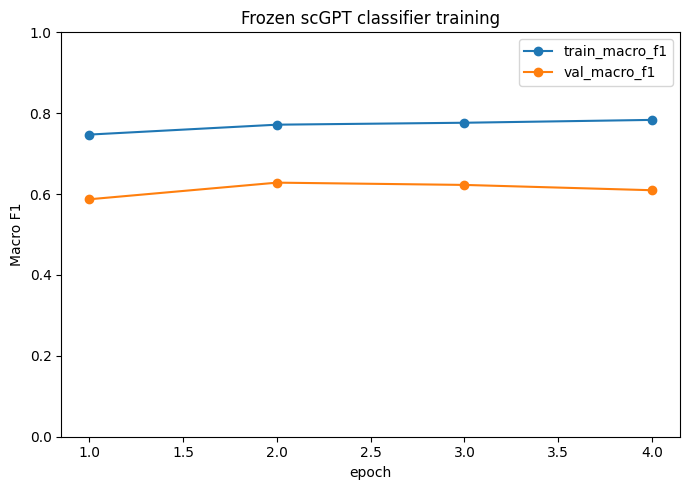

In [66]:
ax = frozen_history_df.plot(
    x="epoch",
    y=[
        "train_macro_f1",
        "val_macro_f1",
    ],
    marker="o",
    figsize=(7, 5),
)

ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1)

ax.set_title(
    "Frozen scGPT classifier training"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "frozen_scgpt_training.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [67]:
assert best_state is not None

frozen_model.load_state_dict(
    best_state
)

frozen_model = frozen_model.to(
    device
)

print(
    f"Best epoch: "
    f"{best_epoch}"
)

print(
    f"Best validation Macro F1: "
    f"{best_val_f1:.4f}"
)

Best epoch: 2
Best validation Macro F1: 0.6283


In [68]:
torch.save(
    {
        "model_state_dict":
            best_state,

        "best_epoch":
            best_epoch,

        "best_val_macro_f1":
            best_val_f1,

        "type2id":
            type2id,

        "id2type":
            id2type,

        "max_seq_len":
            MAX_SEQ_LEN,

        "n_bins":
            N_BINS,
    },

    FROZEN_DIR /
    "best_frozen_scgpt.pt",
)

In [69]:
(
    frozen_test_predictions,
    frozen_test_labels,
    frozen_test_metrics,
) = evaluate_model(
    frozen_model,
    test_loader,
    criterion,
    device,
)

In [70]:
print(
    "FROZEN scGPT TEST RESULTS"
)

print("=" * 45)

for metric, value in (
    frozen_test_metrics.items()
):
    print(
        f"{metric:20s}: "
        f"{value:.4f}"
    )

FROZEN scGPT TEST RESULTS
loss                : 0.6742
accuracy            : 0.9067
balanced_accuracy   : 0.7355
macro_f1            : 0.7486
weighted_f1         : 0.9027


In [71]:
frozen_metrics_df = pd.DataFrame([
    {
        "model":
            "Frozen scGPT",

        "accuracy":
            frozen_test_metrics[
                "accuracy"
            ],

        "balanced_accuracy":
            frozen_test_metrics[
                "balanced_accuracy"
            ],

        "macro_f1":
            frozen_test_metrics[
                "macro_f1"
            ],

        "weighted_f1":
            frozen_test_metrics[
                "weighted_f1"
            ],
    }
])

frozen_metrics_df

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Frozen scGPT,0.906683,0.735549,0.748634,0.902708


In [72]:
frozen_metrics_df.to_csv(
    RESULTS_DIR /
    "frozen_scgpt_metrics.csv",
    index=False,
)

In [73]:
frozen_true = np.array([
    id2type[int(i)]
    for i
    in frozen_test_labels
])

frozen_pred = np.array([
    id2type[int(i)]
    for i
    in frozen_test_predictions
])

In [74]:
frozen_report = pd.DataFrame(
    classification_report(
        frozen_true,
        frozen_pred,

        labels=celltypes,

        output_dict=True,

        zero_division=0,
    )
).T

frozen_report.loc[
    celltypes,
    [
        "precision",
        "recall",
        "f1-score",
        "support",
    ],
]

,precision,recall,f1-score,support
monocyte,0.939569,0.956563,0.947990,7298.0
"CD8-positive, alpha-beta T cell",0.904427,0.896311,0.900351,3009.0
"CD4-positive, alpha-beta T cell",0.852254,0.872151,0.862088,1799.0
B cell,0.921093,0.947983,0.934345,1884.0
natural killer cell,0.664751,0.850490,0.746237,408.0
alpha-beta T cell,0.840909,0.474359,0.606557,468.0
dendritic cell,0.812500,0.774468,0.793028,235.0
platelet,0.866667,0.112069,0.198473,116.0


In [75]:
frozen_report.to_csv(
    RESULTS_DIR /
    "frozen_scgpt_classification_report.csv"
)

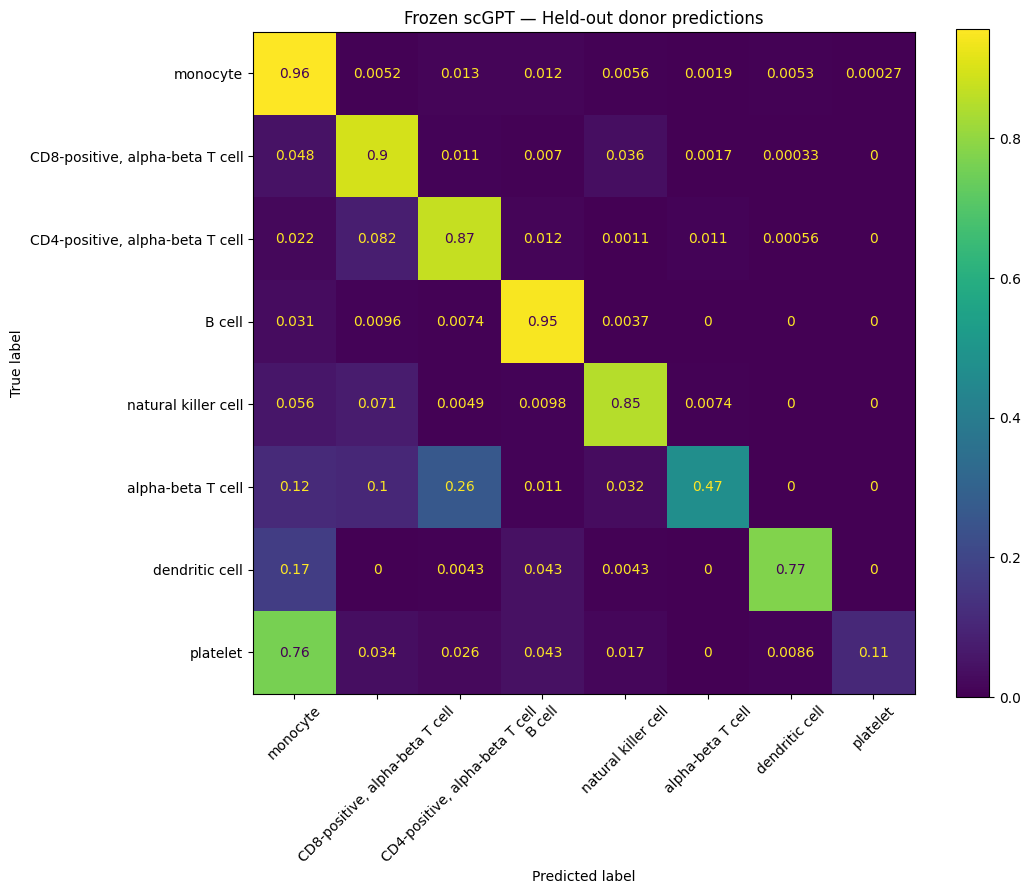

In [76]:
fig, ax = plt.subplots(
    figsize=(11, 9)
)

ConfusionMatrixDisplay.from_predictions(
    frozen_true,
    frozen_pred,

    labels=celltypes,

    normalize="true",

    xticks_rotation=45,

    ax=ax,
)

ax.set_title(
    "Frozen scGPT — "
    "Held-out donor predictions"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "frozen_scgpt_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [91]:
comparison = pd.DataFrame([
    {
        "model":
            "Logistic Regression",

        "accuracy":
            0.860091,

        "balanced_accuracy":
            0.826449,

        "macro_f1":
            0.707006,

        "weighted_f1":
            0.877978,
    },

    {
        "model":
            "Frozen scGPT",

        "accuracy":
            frozen_test_metrics[
                "accuracy"
            ],

        "balanced_accuracy":
            frozen_test_metrics[
                "balanced_accuracy"
            ],

        "macro_f1":
            frozen_test_metrics[
                "macro_f1"
            ],

        "weighted_f1":
            frozen_test_metrics[
                "weighted_f1"
            ],
    },

    {
        "model":
            "Fine-tuned scGPT "
            "(last 2 layers)",

        "accuracy":
            0.910495,

        "balanced_accuracy":
            0.766920,

        "macro_f1":
            0.773823,

        "weighted_f1":
            0.908364,
    },
])

comparison

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Logistic Regression,0.860091,0.826449,0.707006,0.877978
1,Frozen scGPT,0.906683,0.735549,0.748634,0.902708
2,Fine-tuned scGPT (last 2 layers),0.910495,0.766920,0.773823,0.908364


In [92]:
comparison.to_csv(
    RESULTS_DIR /
    "three_model_comparison.csv",
    index=False,
)

In [93]:
logreg = (
    comparison
    .set_index("model")
    .loc["Logistic Regression"]
)

frozen = (
    comparison
    .set_index("model")
    .loc["Frozen scGPT"]
)

finetuned = (
    comparison
    .set_index("model")
    .loc[
        "Fine-tuned scGPT "
        "(last 2 layers)"
    ]
)

In [94]:
improvements = pd.DataFrame({
    "comparison": [
        "Frozen - Logistic",
        "Fine-tuned - Frozen",
        "Fine-tuned - Logistic",
    ],

    "accuracy_difference": [
        frozen["accuracy"]
        - logreg["accuracy"],

        finetuned["accuracy"]
        - frozen["accuracy"],

        finetuned["accuracy"]
        - logreg["accuracy"],
    ],

    "macro_f1_difference": [
        frozen["macro_f1"]
        - logreg["macro_f1"],

        finetuned["macro_f1"]
        - frozen["macro_f1"],

        finetuned["macro_f1"]
        - logreg["macro_f1"],
    ],

    "balanced_accuracy_difference": [
        frozen["balanced_accuracy"]
        - logreg["balanced_accuracy"],

        finetuned["balanced_accuracy"]
        - frozen["balanced_accuracy"],

        finetuned["balanced_accuracy"]
        - logreg["balanced_accuracy"],
    ],
})

improvements

,comparison,accuracy_difference,macro_f1_difference,balanced_accuracy_difference
0,Frozen - Logistic,0.046592,0.041628,-0.090900
1,Fine-tuned - Frozen,0.003812,0.025189,0.031371
2,Fine-tuned - Logistic,0.050404,0.066817,-0.059529


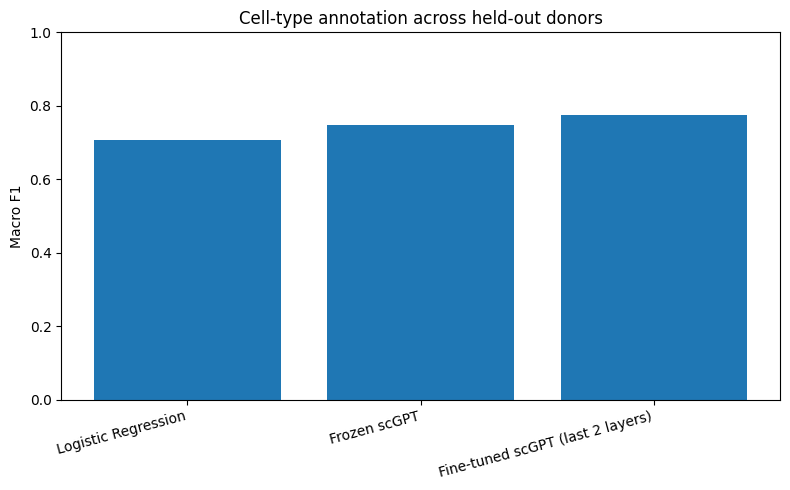

In [95]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    comparison["model"],
    comparison["macro_f1"],
)

ax.set_ylabel("Macro F1")

ax.set_ylim(
    0,
    1,
)

ax.set_title(
    "Cell-type annotation "
    "across held-out donors"
)

plt.xticks(
    rotation=15,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "three_model_macro_f1.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

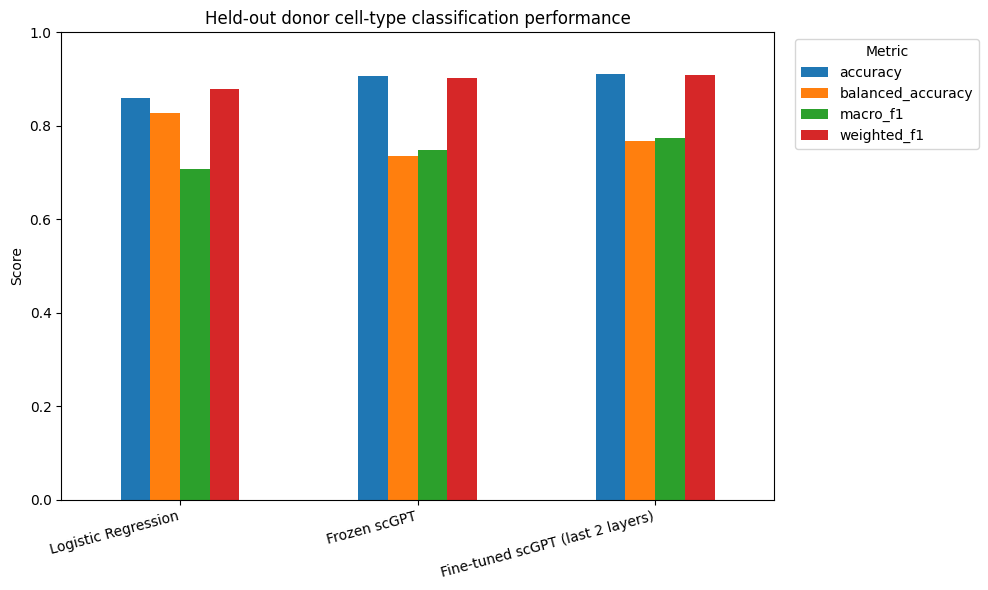

In [96]:
plot_df = (
    comparison
    .set_index("model")
    [
        [
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "weighted_f1",
        ]
    ]
)

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6),
)

ax.set_ylabel("Score")
ax.set_ylim(0, 1)

ax.set_xlabel("")

ax.set_title(
    "Held-out donor cell-type "
    "classification performance"
)

plt.xticks(
    rotation=15,
    ha="right",
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(
        1.02,
        1,
    ),
    loc="upper left",
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "three_model_all_metrics.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [97]:
baseline_report = pd.read_csv(
    RESULTS_DIR /
    "baseline_classification_report.csv",

    index_col=0,
)

finetuned_report = pd.read_csv(
    RESULTS_DIR /
    "scgpt_classification_report.csv",

    index_col=0,
)

per_class = []

for cell_type in celltypes:

    per_class.append({
        "cell_type":
            cell_type,

        "logreg_recall":
            baseline_report.loc[
                cell_type,
                "recall",
            ],

        "frozen_recall":
            frozen_report.loc[
                cell_type,
                "recall",
            ],

        "finetuned_recall":
            finetuned_report.loc[
                cell_type,
                "recall",
            ],

        "logreg_f1":
            baseline_report.loc[
                cell_type,
                "f1-score",
            ],

        "frozen_f1":
            frozen_report.loc[
                cell_type,
                "f1-score",
            ],

        "finetuned_f1":
            finetuned_report.loc[
                cell_type,
                "f1-score",
            ],
    })

In [98]:
per_class_df = pd.DataFrame(
    per_class
)

per_class_df

,cell_type,logreg_recall,frozen_recall,finetuned_recall,logreg_f1,frozen_f1,finetuned_f1
0,monocyte,0.846670,0.956563,0.973828,0.909680,0.947990,0.957043
1,"CD8-positive, alpha-beta T cell",0.863410,0.896311,0.826520,0.893859,0.900351,0.889326
2,"CD4-positive, alpha-beta T cell",0.874931,0.872151,0.931073,0.871539,0.862088,0.872396
3,B cell,0.938960,0.947983,0.941083,0.933263,0.934345,0.942333
4,natural killer cell,0.872549,0.850490,0.870098,0.717019,0.746237,0.705765
5,alpha-beta T cell,0.705128,0.474359,0.495726,0.535280,0.606557,0.630435
6,dendritic cell,0.897872,0.774468,0.829787,0.590210,0.793028,0.805785
7,platelet,0.612069,0.112069,0.267241,0.205202,0.198473,0.387500


In [99]:
per_class_df.to_csv(
    RESULTS_DIR /
    "three_model_per_class.csv",
    index=False,
)

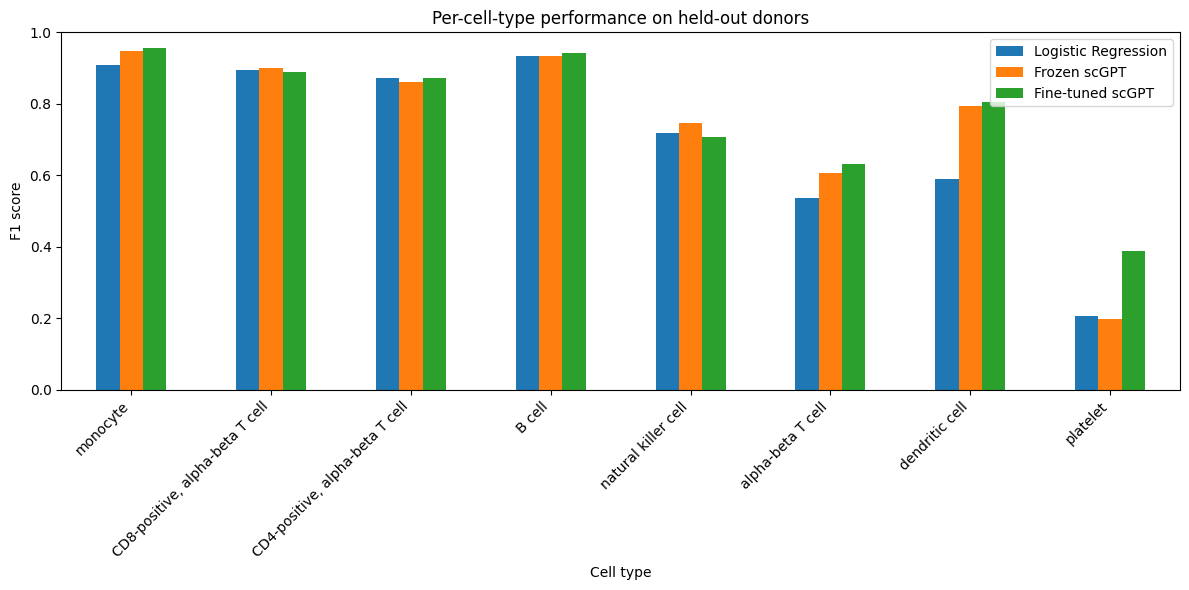

In [100]:
plot_f1 = (
    per_class_df
    .set_index("cell_type")
    [
        [
            "logreg_f1",
            "frozen_f1",
            "finetuned_f1",
        ]
    ]
)

plot_f1.columns = [
    "Logistic Regression",
    "Frozen scGPT",
    "Fine-tuned scGPT",
]

ax = plot_f1.plot(
    kind="bar",
    figsize=(12, 6),
)

ax.set_ylabel("F1 score")
ax.set_ylim(0, 1)

ax.set_xlabel("Cell type")

ax.set_title(
    "Per-cell-type performance "
    "on held-out donors"
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "three_model_per_class_f1.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

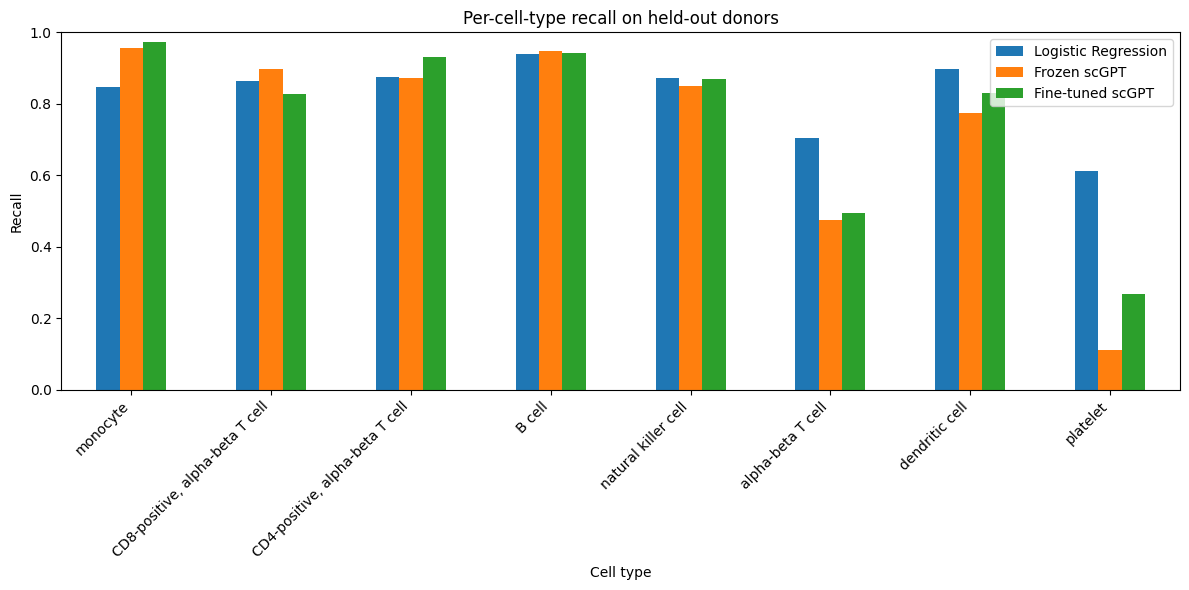

In [101]:
plot_recall = (
    per_class_df
    .set_index("cell_type")
    [
        [
            "logreg_recall",
            "frozen_recall",
            "finetuned_recall",
        ]
    ]
)

plot_recall.columns = [
    "Logistic Regression",
    "Frozen scGPT",
    "Fine-tuned scGPT",
]

ax = plot_recall.plot(
    kind="bar",
    figsize=(12, 6),
)

ax.set_ylabel("Recall")
ax.set_ylim(0, 1)

ax.set_xlabel("Cell type")

ax.set_title(
    "Per-cell-type recall "
    "on held-out donors"
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "three_model_per_class_recall.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()